# TwoParticleSparseBlockEncoding Benchmark and Scaling Fit

This notebook:
1. Builds benchmark `V` tensors in oracle convention (`direct` or `exchange`).
2. Constructs `TwoParticleSparseBlockEncoding`.
3. Extracts gate counts / logical qubits / surface-code runtime+footprint.
4. Fits scaling exponents and constant factors in terms of `L, R_c, R_loc, D`.


In [17]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

from qualtran.resource_counting import GateCounts, QECGatesCost, QubitCount, get_cost_value
from qualtran.surface_code import CCZ2TFactory, MultiFactory, SimpleDataBlock
from qualtran.surface_code.gidney_fowler_model import get_ccz2t_costs

if (Path.cwd() / 'src').exists():
    REPO_ROOT = Path.cwd()
elif (Path.cwd().parent / 'src').exists():
    REPO_ROOT = Path.cwd().parent
else:
    REPO_ROOT = Path.cwd()

SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from exciton.benchmark_tensors import generate_v_tensor
from integrations.qualtran.block_encoding.two_particle_row_oracles import build_two_particle_sparse_block_encoding


In [18]:
# -------- Configuration --------
# Main demonstration point
D = 1
L_demo = 8
R_loc_demo = 1
R_c_demo = 1
entry_bitsize = 8
metric = 'chebyshev'
convention = 'direct'  # 'direct' or 'exchange'

# Surface-code model assumptions
query_repetitions = 50_000
phys_err = 1e-3
cycle_time_us = 1.0
factory = MultiFactory(CCZ2TFactory(distillation_l1_d=19, distillation_l2_d=31), n_factories=4)
data_block = SimpleDataBlock(data_d=31, routing_overhead=0.5)

# Tiered sweep plans (more points without memory blow-up):
# Each dict is a Cartesian sweep over D x Ls x Rcs x Rls.
sweep_plan = [
    dict(D=1, Ls=[2, 4, 8, 16, 32, 64], Rcs=[1, 2, 3, 4, 5], Rls=[1, 2, 3, 4, 5]),
    dict(D=2, Ls=[2, 4, 8],             Rcs=[1, 2, 3],       Rls=[1, 2, 3]),
    dict(D=3, Ls=[2, 4],                Rcs=[1],             Rls=[1]),
]


In [19]:
# -------- Single construction demo --------
M_demo = generate_v_tensor(
    L=L_demo, D=D, r_loc=R_loc_demo, r_c=R_c_demo, metric=metric, oracle_convention=convention
)
oracle_demo = build_two_particle_sparse_block_encoding(
    M=M_demo, D=D, L=L_demo, R_c=R_c_demo, R_loc=R_loc_demo, entry_bitsize=entry_bitsize
)

print('M_demo shape:', M_demo.shape)
print('oracle type:', type(oracle_demo).__name__)
print('oracle signature:', oracle_demo.signature)

qec_demo = get_cost_value(oracle_demo, QECGatesCost())
qec_dict_demo = qec_demo.asdict() if hasattr(qec_demo, 'asdict') else vars(qec_demo)
print('QEC counts (single query):', qec_dict_demo)


M_demo shape: (8, 8, 3, 3)
oracle type: TwoParticleSparseBlockEncoding
oracle signature: Signature((Register(name='q', dtype=QBit(), _shape=(), side=<Side.THRU: 3>), Register(name='m', dtype=BQUInt(bitsize=2, iteration_length=3), _shape=(1,), side=<Side.THRU: 3>), Register(name='l', dtype=BQUInt(bitsize=2, iteration_length=3), _shape=(1,), side=<Side.THRU: 3>), Register(name='i', dtype=BQUInt(bitsize=3, iteration_length=8), _shape=(1,), side=<Side.THRU: 3>), Register(name='j', dtype=BQUInt(bitsize=3, iteration_length=8), _shape=(1,), side=<Side.THRU: 3>)))
QEC counts (single query): {'and_bloq': 480, 'clifford': 1911, 'rotation': 16, 'measurement': 480}


In [20]:
# -------- Sweep and collect metrics --------
def toffoli_like(qec_dict: dict) -> int:
    return int(qec_dict.get('toffoli', 0) + qec_dict.get('and_bloq', 0) + qec_dict.get('cswap', 0))

rows = []
for cfg in sweep_plan:
    d = int(cfg['D'])
    for l in cfg['Ls']:
        for rc in cfg['Rcs']:
            for rloc in cfg['Rls']:
                M = generate_v_tensor(
                    L=l, D=d, r_loc=rloc, r_c=rc, metric=metric, oracle_convention=convention
                )
                bloq = build_two_particle_sparse_block_encoding(
                    M=M, D=d, L=l, R_c=rc, R_loc=rloc, entry_bitsize=entry_bitsize
                )

                qec = get_cost_value(bloq, QECGatesCost())
                qec_dict = qec.asdict() if hasattr(qec, 'asdict') else vars(qec)

                toff = toffoli_like(qec_dict)
                cliff = int(qec_dict.get('clifford', 0))
                rot = int(qec_dict.get('rotation', 0))
                t_explicit = int(qec_dict.get('t', 0))
                n_algo_qubits = int(get_cost_value(bloq, QubitCount()))

                total_toff = int(query_repetitions * toff)
                physical = get_ccz2t_costs(
                    n_logical_gates=GateCounts(toffoli=total_toff),
                    n_algo_qubits=n_algo_qubits,
                    phys_err=phys_err,
                    cycle_time_us=cycle_time_us,
                    factory=factory,
                    data_block=data_block,
                )

                rows.append({
                    'D': d,
                    'L': l,
                    'R_c': rc,
                    'R_loc': rloc,
                    'M_shape': M.shape,
                    'algo_qubits': n_algo_qubits,
                    'toffoli_like': toff,
                    'clifford': cliff,
                    'rotation': rot,
                    't_explicit': t_explicit,
                    'runtime_hours': float(physical.duration_hr),
                    'footprint_mqubits': float(physical.footprint) / 1e6,
                    'failure_prob': float(physical.failure_prob),
                })

print(f'Collected {len(rows)} points.')
rows[:3]


Collected 179 points.


[{'D': 1,
  'L': 2,
  'R_c': 1,
  'R_loc': 1,
  'M_shape': (2, 2, 3, 3),
  'algo_qubits': 20,
  'toffoli_like': 68,
  'clifford': 347,
  'rotation': 16,
  't_explicit': 0,
  'runtime_hours': 0.050645833333333334,
  'footprint_mqubits': 0.858172,
  'failure_prob': 4.043837678200003e-07},
 {'D': 1,
  'L': 2,
  'R_c': 1,
  'R_loc': 2,
  'M_shape': (2, 2, 3, 5),
  'algo_qubits': 22,
  'toffoli_like': 98,
  'clifford': 505,
  'rotation': 16,
  't_explicit': 0,
  'runtime_hours': 0.07298958333333333,
  'footprint_mqubits': 0.863938,
  'failure_prob': 5.906712462700003e-07},
 {'D': 1,
  'L': 2,
  'R_c': 1,
  'R_loc': 3,
  'M_shape': (2, 2, 3, 7),
  'algo_qubits': 22,
  'toffoli_like': 130,
  'clifford': 659,
  'rotation': 16,
  't_explicit': 0,
  'runtime_hours': 0.09682291666666666,
  'footprint_mqubits': 0.863938,
  'failure_prob': 7.835434899500005e-07}]

In [21]:
# Compact table view
for r in rows:
    print(
        f"D={r['D']} L={r['L']:>2} Rc={r['R_c']} Rloc={r['R_loc']} | "
        f"toff={r['toffoli_like']:>5} cliff={r['clifford']:>5} rot={r['rotation']:>3} | "
        f"runtime_h={r['runtime_hours']:.5g} mqubits={r['footprint_mqubits']:.5g}"
    )


D=1 L= 2 Rc=1 Rloc=1 | toff=   68 cliff=  347 rot= 16 | runtime_h=0.050646 mqubits=0.85817
D=1 L= 2 Rc=1 Rloc=2 | toff=   98 cliff=  505 rot= 16 | runtime_h=0.07299 mqubits=0.86394
D=1 L= 2 Rc=1 Rloc=3 | toff=  130 cliff=  659 rot= 16 | runtime_h=0.096823 mqubits=0.86394
D=1 L= 2 Rc=1 Rloc=4 | toff=  152 cliff=  765 rot= 16 | runtime_h=0.11321 mqubits=0.8697
D=1 L= 2 Rc=1 Rloc=5 | toff=  184 cliff=  919 rot= 16 | runtime_h=0.13704 mqubits=0.8697
D=1 L= 2 Rc=2 Rloc=1 | toff=   98 cliff=  487 rot= 16 | runtime_h=0.07299 mqubits=0.86394
D=1 L= 2 Rc=2 Rloc=2 | toff=  144 cliff=  673 rot= 16 | runtime_h=0.10725 mqubits=0.8697
D=1 L= 2 Rc=2 Rloc=3 | toff=  192 cliff=  911 rot= 16 | runtime_h=0.143 mqubits=0.8697
D=1 L= 2 Rc=2 Rloc=4 | toff=  230 cliff= 1045 rot= 16 | runtime_h=0.1713 mqubits=0.87547
D=1 L= 2 Rc=2 Rloc=5 | toff=  278 cliff= 1283 rot= 16 | runtime_h=0.20705 mqubits=0.87547
D=1 L= 2 Rc=3 Rloc=1 | toff=  130 cliff=  651 rot= 16 | runtime_h=0.096823 mqubits=0.86394
D=1 L= 2 Rc=3 

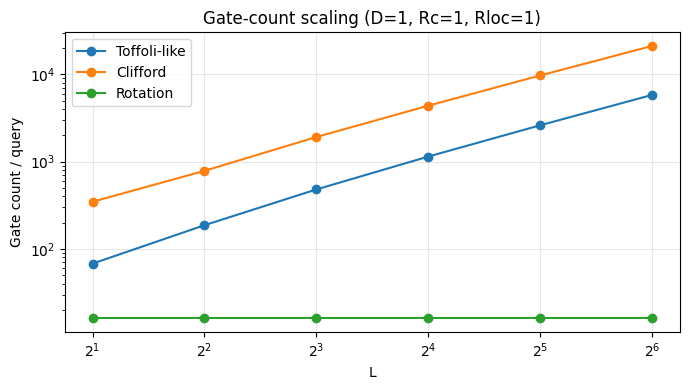

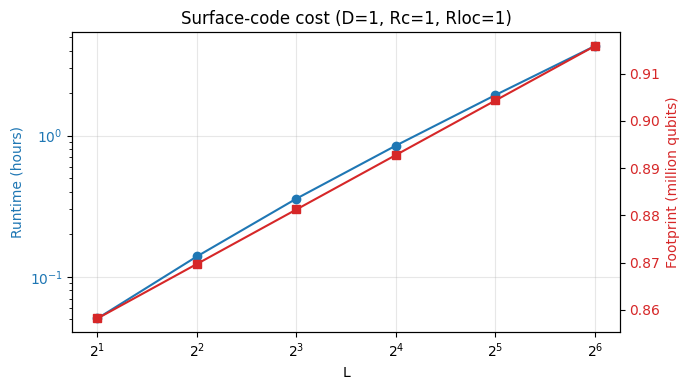

In [22]:
# -------- Plot examples (for D=1, Rc=1, Rloc=1) vs L --------
sub = [r for r in rows if r['D'] == 1 and r['R_c'] == 1 and r['R_loc'] == 1]
sub = sorted(sub, key=lambda x: x['L'])

L = np.array([r['L'] for r in sub], dtype=float)
toff = np.array([r['toffoli_like'] for r in sub], dtype=float)
cliff = np.array([r['clifford'] for r in sub], dtype=float)
rot = np.array([r['rotation'] for r in sub], dtype=float)
runtime = np.array([r['runtime_hours'] for r in sub], dtype=float)
mqubits = np.array([r['footprint_mqubits'] for r in sub], dtype=float)

plt.figure(figsize=(7, 4))
plt.plot(L, toff, marker='o', label='Toffoli-like')
plt.plot(L, cliff, marker='o', label='Clifford')
plt.plot(L, rot, marker='o', label='Rotation')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('L')
plt.ylabel('Gate count / query')
plt.title('Gate-count scaling (D=1, Rc=1, Rloc=1)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(L, runtime, marker='o', color='tab:blue', label='Runtime (hours)')
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.set_xlabel('L')
ax1.set_ylabel('Runtime (hours)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(L, mqubits, marker='s', color='tab:red', label='Footprint (M qubits)')
ax2.set_ylabel('Footprint (million qubits)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Surface-code cost (D=1, Rc=1, Rloc=1)')
fig.tight_layout()
plt.show()


In [ ]:
# -------- Scaling fits + constant factors + bootstrap CIs --------
def fit_power_law_D_in_exponent(rows, target_key, include_D_prefactor=False):
    # Model A (recommended):
    #   target ~ C * (L^a * (2Rc+1)^b * (2Rloc+1)^c)^D
    # Optional extension:
    #   target ~ C * (L^a * (2Rc+1)^b * (2Rloc+1)^c)^D * D^d
    y = np.array([max(1e-30, float(r[target_key])) for r in rows], dtype=float)
    L = np.array([float(r['L']) for r in rows], dtype=float)
    Rc = np.array([float(r['R_c']) for r in rows], dtype=float)
    Rloc = np.array([float(r['R_loc']) for r in rows], dtype=float)
    D = np.array([float(r['D']) for r in rows], dtype=float)

    cols = [
        np.ones_like(y),
        D * np.log(L),
        D * np.log(2.0 * Rc + 1.0),
        D * np.log(2.0 * Rloc + 1.0),
    ]
    if include_D_prefactor:
        cols.append(np.log(D))

    X = np.column_stack(cols)
    beta = np.linalg.lstsq(X, np.log(y), rcond=None)[0]

    out = {
        'C': float(np.exp(beta[0])),
        'a_L': float(beta[1]),
        'b_Rc': float(beta[2]),
        'c_Rloc': float(beta[3]),
    }
    if include_D_prefactor:
        out['d_D_prefactor'] = float(beta[4])
    return out


def fit_fixed_structure_constant(rows, target_key):
    # target ~ C * ((L^2 * (2Rc+1) * (2Rloc+1))^D)
    x = np.array(
        [
            (float(r['L']) ** 2 * (2.0 * float(r['R_c']) + 1.0) * (2.0 * float(r['R_loc']) + 1.0))
            ** float(r['D'])
            for r in rows
        ],
        dtype=float,
    )
    y = np.array([float(r[target_key]) for r in rows], dtype=float)
    return float((x @ y) / (x @ x))


def bootstrap_fit_ci(rows, target_key, include_D_prefactor=False, n_boot=300, seed=0):
    rng = np.random.default_rng(seed)
    n = len(rows)
    keys = ['C', 'a_L', 'b_Rc', 'c_Rloc']
    if include_D_prefactor:
        keys.append('d_D_prefactor')

    vals = {k: [] for k in keys}
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        sample = [rows[int(i)] for i in idx]
        fit = fit_power_law_D_in_exponent(sample, target_key, include_D_prefactor=include_D_prefactor)
        for k in keys:
            vals[k].append(float(fit[k]))

    summary = {}
    for k in keys:
        arr = np.array(vals[k], dtype=float)
        summary[k] = {
            'mean': float(np.mean(arr)),
            'p2.5': float(np.percentile(arr, 2.5)),
            'p97.5': float(np.percentile(arr, 97.5)),
        }
    return summary


def bootstrap_fixed_C_ci(rows, target_key, n_boot=300, seed=0):
    rng = np.random.default_rng(seed)
    n = len(rows)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        sample = [rows[int(i)] for i in idx]
        vals.append(fit_fixed_structure_constant(sample, target_key))
    arr = np.array(vals, dtype=float)
    return {
        'mean': float(np.mean(arr)),
        'p2.5': float(np.percentile(arr, 2.5)),
        'p97.5': float(np.percentile(arr, 97.5)),
    }


for key in ['toffoli_like', 'clifford', 'rotation', 'runtime_hours', 'footprint_mqubits']:
    pl = fit_power_law_D_in_exponent(rows, key, include_D_prefactor=False)
    pl_ext = fit_power_law_D_in_exponent(rows, key, include_D_prefactor=True)
    cfix = fit_fixed_structure_constant(rows, key)

    ci = bootstrap_fit_ci(rows, key, include_D_prefactor=False, n_boot=300, seed=7)
    ci_ext = bootstrap_fit_ci(rows, key, include_D_prefactor=True, n_boot=300, seed=7)
    ci_cfix = bootstrap_fixed_C_ci(rows, key, n_boot=300, seed=7)

    print(f'[{key}]')
    print('  Point estimate (D-in-exponent):', pl)
    print('  95% CI (bootstrap):', ci)
    print('  Point estimate (D-in-exponent + D^d):', pl_ext)
    print('  95% CI (bootstrap):', ci_ext)
    print('  Fixed-structure C point estimate:', cfix)
    print('  Fixed-structure C 95% CI (bootstrap):', ci_cfix)
    print()


[toffoli_like]
  Point estimate (D-in-exponent): {'C': 1.8687654628553332, 'a_L': 1.3688328687048865, 'b_Rc': 0.8607804135530851, 'c_Rloc': 1.3391350295278805}
  95% CI (bootstrap): {'C': {'mean': 1.8874415596995304, 'p2.5': 1.6091138237773455, 'p97.5': 2.217096128295212}, 'a_L': {'mean': 1.368075817862588, 'p2.5': 1.3323863829400706, 'p97.5': 1.4060334834442232}, 'b_Rc': {'mean': 0.8600618242386023, 'p2.5': 0.7997838649223464, 'p97.5': 0.9214957521062019}, 'c_Rloc': {'mean': 1.3375533806778366, 'p2.5': 1.265655760591503, 'p97.5': 1.405646829929703}}
  Point estimate (D-in-exponent + D^d): {'C': 2.2069661525991338, 'a_L': 1.366206023647758, 'b_Rc': 0.8146517769223818, 'c_Rloc': 1.293006392897177, 'd_D_prefactor': 0.25484836086494633}
  95% CI (bootstrap): {'C': {'mean': 2.22326300701744, 'p2.5': 1.7948255725313402, 'p97.5': 2.6186920043537665}, 'a_L': {'mean': 1.3654802471360394, 'p2.5': 1.328953421940094, 'p97.5': 1.4026203519925902}, 'b_Rc': {'mean': 0.8148362502040821, 'p2.5': 0.739

: 

## Notes
- The primary power-law fit now uses `D` inside exponents:
  `target ~ C * (L^a * (2R_c+1)^b * (2R_loc+1)^c)^D`.
- An extended variant additionally fits a residual prefactor `D^d`.
- The fixed-structure constant fit enforces
  `target ~ C * ((L^2 * (2R_c+1) * (2R_loc+1))^D)`.
- `L` values should be powers of two for exact decomposition path in the current index oracle implementation.
